# CAA Project - Deep Learning Approaches for Pneumonia Detection: A Comparative Study on Chest X-Ray Images

**Data Exploration and Analysis Notebook**

Authors:
- Rafaela Abrunhosa, 107658
- Miguel Pinto, 107449

# External Libraries

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # added for the tables TODO

# Load the data

- NOTE: We could be using the direct code by importing the official medmnist library, but it installs PyTorch dependencies and we intend to use Tensorflow.

Train - images: (4708, 28, 28)  labels: (4708, 1)
Test  - images: (624, 28, 28)  labels: (624, 1)
Val   - images: (524, 28, 28)  labels: (524, 1)

Distribution of labels in each set:
Training set   - Normal: 1214, Pneumonia: 3494
Testing set    - Normal: 234, Pneumonia: 390
Validation set - Normal: 135, Pneumonia: 389


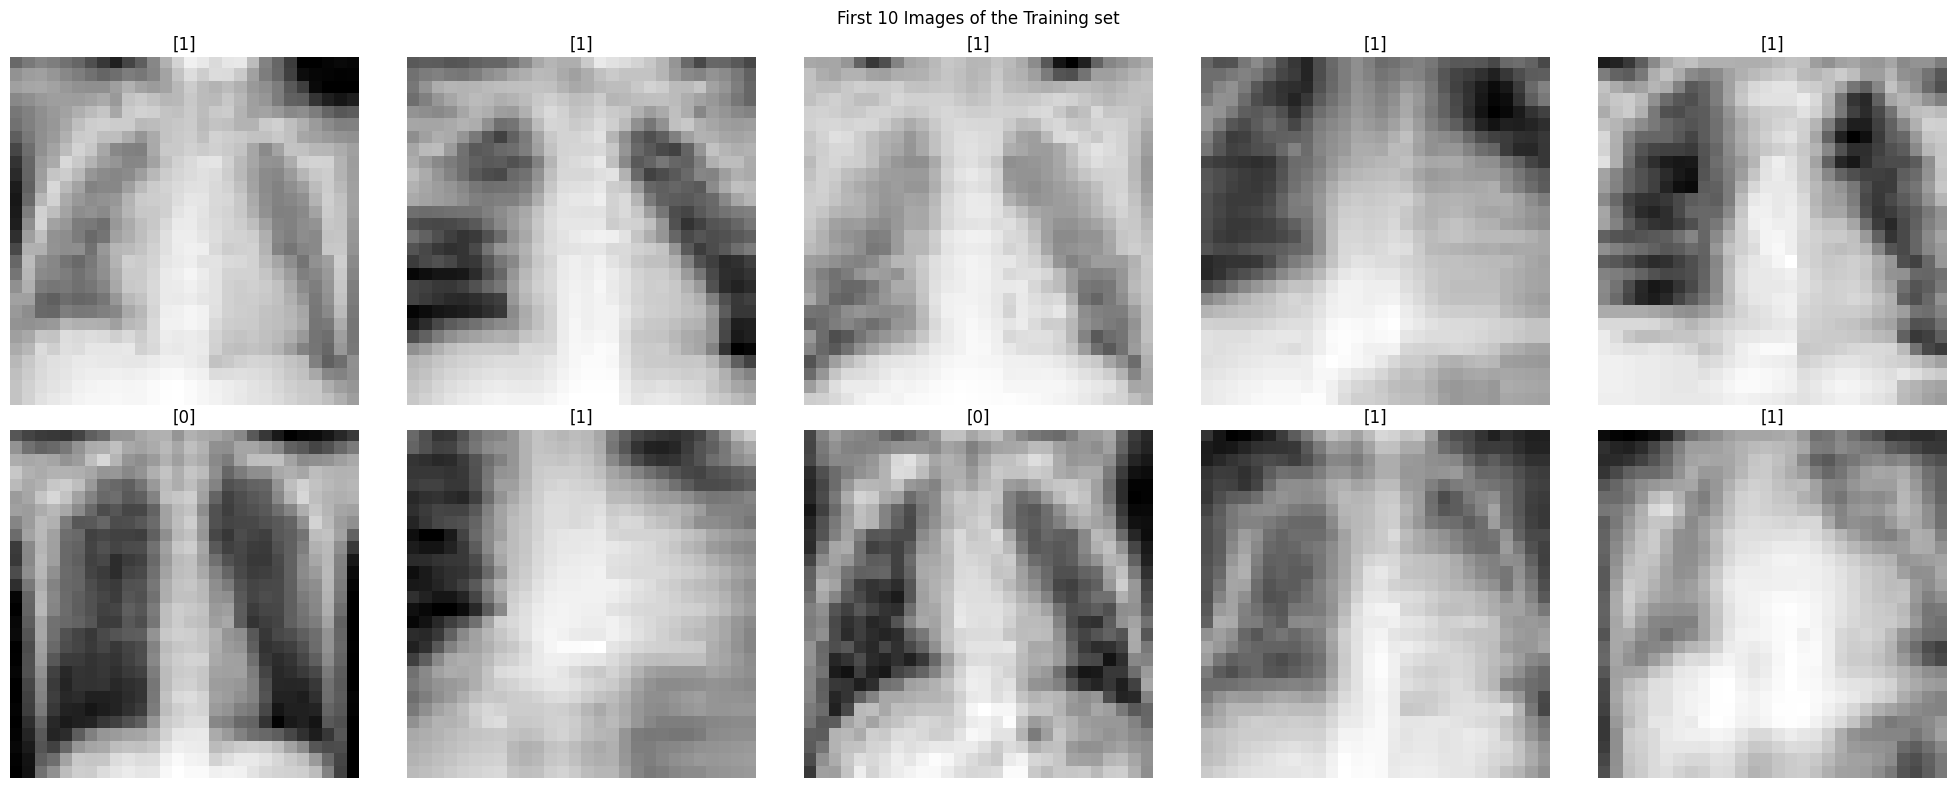

In [81]:
# Load the files for the training, testing and validation sets
train_images = np.load("data/train_images.npy")
train_labels = np.load("data/train_labels.npy")
test_images  = np.load("data/test_images.npy")
test_labels  = np.load("data/test_labels.npy")
val_images   = np.load("data/val_images.npy")
val_labels   = np.load("data/val_labels.npy")

# Print the shapes of the data
print("Train - images:", train_images.shape, " labels:", train_labels.shape)
print("Test  - images:", test_images.shape, " labels:", test_labels.shape)
print("Val   - images:", val_images.shape, " labels:", val_labels.shape)

# Check the unique labels in all sets
unique_train, counts_train = np.unique(train_labels, return_counts=True)
unique_test, counts_test   = np.unique(test_labels, return_counts=True)
unique_val, counts_val     = np.unique(val_labels, return_counts=True)

print("\nDistribution of labels in each set:")
print("Training set   - Normal: {}, Pneumonia: {}".format(counts_train[0], counts_train[1]))
print("Testing set    - Normal: {}, Pneumonia: {}".format(counts_test[0], counts_test[1]))
print("Validation set - Normal: {}, Pneumonia: {}".format(counts_val[0], counts_val[1]))

# Plot 10 images in a 2x5 grid from the training set
num_images = 10
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i in range(2):
    for j in range(5):
        idx = i * 5 + j
        axs[i,j].imshow(train_images[idx], cmap='gray')
        axs[i,j].set_title(train_labels[idx])
        axs[i,j].axis('off')
plt.suptitle(f"First {num_images} Images of the Training set")
plt.tight_layout()
plt.show()

# Data Exploration

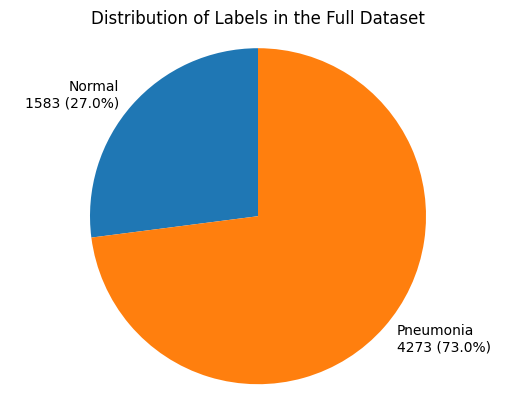


Distribution of labels in the full dataset:

           Count  Percentage
Label                       
Normal      1583   27.032104
Pneumonia   4273   72.967896


In [82]:
# Pie chart with the distribution of labels overall
labels = ['Normal', 'Pneumonia']
sizes = [counts_train[0] + counts_test[0] + counts_val[0], counts_train[1] + counts_test[1] + counts_val[1]]

# Calculate percentages and create custom labels
total = sum(sizes)
percentages = [s/total*100 for s in sizes]
labels = [f'{labels[i]}\n{sizes[i]} ({percentages[i]:.1f}%)' for i in range(len(labels))]

fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct='', startangle=90)
ax1.axis('equal')
plt.title("Distribution of Labels in the Full Dataset")
plt.show()

# Table with the distribution of labels in the full dataset
data = {'Label': ['Normal', 'Pneumonia'], 
        'Count': [sizes[0], sizes[1]], 
        'Percentage': [percentages[0], percentages[1]]}
df = pd.DataFrame(data)
df.set_index('Label', inplace=True)
print("\nDistribution of labels in the full dataset:\n")
print(df)

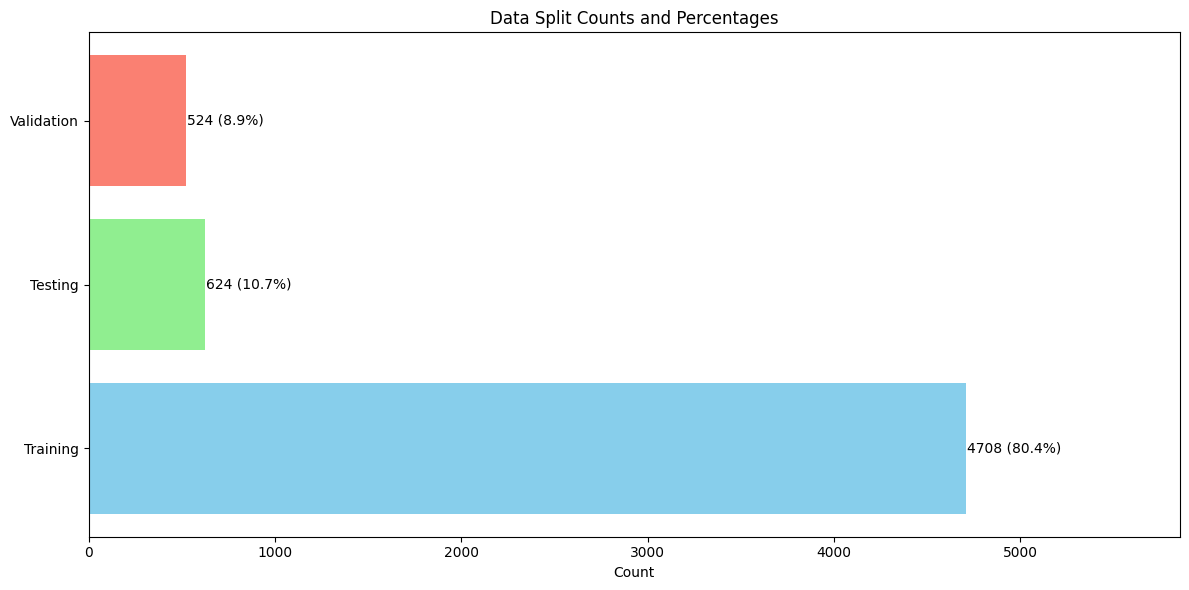


Data Split Counts and Percentages:

            Count Percentage
Set                         
Training     4708      80.4%
Testing       624      10.7%
Validation    524       8.9%


In [83]:
# Calculate totals for each dataset
total_train = counts_train[0] + counts_train[1]
total_test  = counts_test[0] + counts_test[1]
total_val   = counts_val[0] + counts_val[1]
total_all   = total_train + total_test + total_val

# Labels and counts for each split
split_labels = ['Training', 'Testing', 'Validation']
split_counts = [total_train, total_test, total_val]

colors = ['skyblue', 'lightgreen', 'salmon']

# Horizontal Bar Chart (Sidebar) for Data Split
plt.figure(figsize=(12,6))
bars = plt.barh(split_labels, split_counts, color=colors)
for bar, count in zip(bars, split_counts):
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2,
            f'{count} ({count/total_all*100:.1f}%)', va='center', fontsize=10)
plt.xlim(0, total_all)
plt.title('Data Split Counts and Percentages')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

# Table with the data split counts and percentages
data = {'Set': split_labels,
        'Count': split_counts,
        'Percentage': [f'{c/total_all*100:.1f}%' for c in split_counts]}
df = pd.DataFrame(data)
df.set_index('Set', inplace=True)
print("\nData Split Counts and Percentages:\n")
print(df)

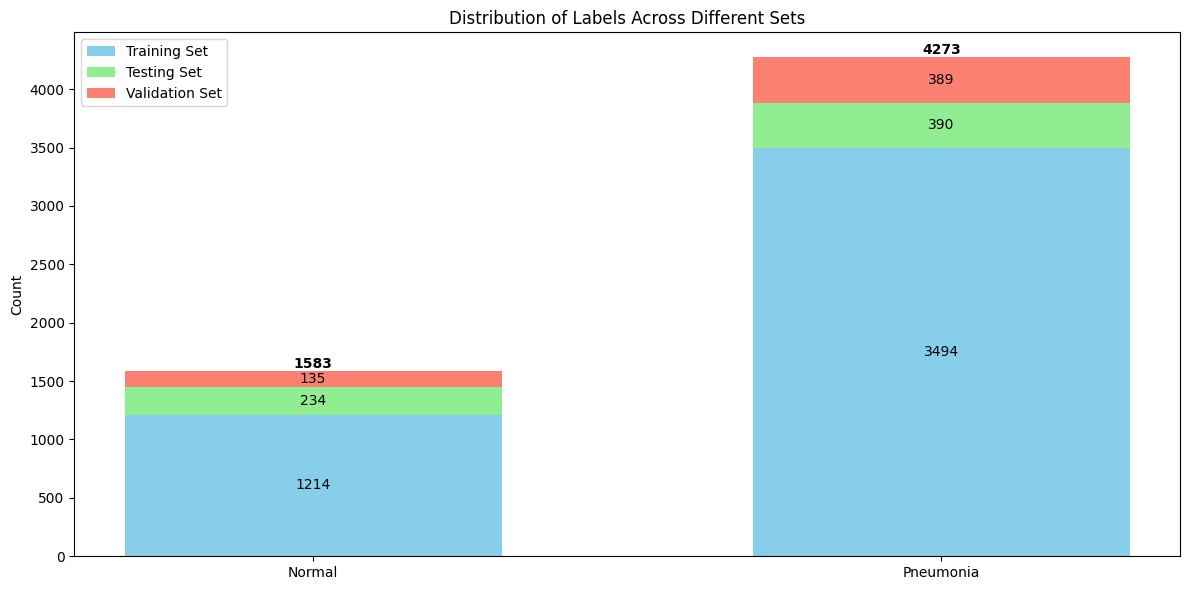


Distribution of labels accross different sets:

            Normal  Pneumonia
Set                          
Training      1214       3494
Testing        234        390
Validation     135        389
TOTAL         1583       4273


In [84]:
# Create stacked bar chart with individual segment annotations
width = 0.6
labels = ['Normal', 'Pneumonia']

plt.figure(figsize=(12, 6))

# Calculate totals for each label
total_normal = counts_train[0] + counts_test[0] + counts_val[0]
total_pneumonia = counts_train[1] + counts_test[1] + counts_val[1]

# Plot stacked bars for each set
plt.bar(labels, [counts_train[0], counts_train[1]], width,
        label='Training Set', color='skyblue')
plt.bar(labels, [counts_test[0], counts_test[1]], width,
        bottom=[counts_train[0], counts_train[1]],
        label='Testing Set', color='lightgreen')
plt.bar(labels, [counts_val[0], counts_val[1]], width,
        bottom=[counts_train[0] + counts_test[0], counts_train[1] + counts_test[1]],
        label='Validation Set', color='salmon')

# Annotate each segment with its value
for i, label in enumerate(labels):
    # Training set annotation
    train_val = counts_train[i]
    plt.text(i, train_val/2, str(train_val),
            ha='center', va='center', color='black')
    
    # Testing set annotation
    test_val = counts_test[i]
    plt.text(i, counts_train[i] + test_val/2, str(test_val),
            ha='center', va='center', color='black')
    
    # Validation set annotation
    val_val = counts_val[i]
    plt.text(i, counts_train[i] + counts_test[i] + val_val/2, str(val_val),
            ha='center', va='center', color='black')
    
    # Add the total on top of the bar
    total = total_normal if i == 0 else total_pneumonia
    plt.text(i, total, str(total), ha='center', va='bottom', fontweight='bold')

plt.ylabel('Count')
plt.title('Distribution of Labels Across Different Sets')
plt.legend()
plt.tight_layout()
plt.show()

# Table with the distribution of labels accross different sets
data = {'Set': ['Training', 'Testing', 'Validation', 'TOTAL'],
        'Normal': [counts_train[0], counts_test[0], counts_val[0], total_normal],
        'Pneumonia': [counts_train[1], counts_test[1], counts_val[1], total_pneumonia]}
df = pd.DataFrame(data)
df.set_index('Set', inplace=True)
print("\nDistribution of labels accross different sets:\n")
print(df)